# Esquema MVP: CNN en CIFAR-10 (PyTorch)

Clasificación de imágenes **32×32** en **10 clases** con una CNN mínima.

| Paso | Contenido |
|------|-----------|
| 1–5 | Datos, transforms, split train/val/test, `DataLoader` |
| 6 | Arquitectura `CifarCNN` |
| 7 | Entrenamiento (solo train) |
| 8 | Análisis comparativo (val → elegir, test → evaluar) |

> Ejecuta desde `14-computer-vision-cnn/`. La primera vez descarga CIFAR-10 en `data/`.


## 1. Imports y dispositivo


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")


Dispositivo: cuda


## 2. CIFAR-10 y clases


In [2]:
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
NUM_CLASSES = len(CLASS_NAMES)

# Descarga en ./data (solo la primera vez)
raw_train = datasets.CIFAR10(root="data", train=True, download=True)
raw_test = datasets.CIFAR10(root="data", train=False, download=True)

print(f"Train oficial: {len(raw_train):,} imágenes")
print(f"Test oficial:  {len(raw_test):,} imágenes")
print(f"Clases ({NUM_CLASSES}):", CLASS_NAMES)


100.0%


Train oficial: 50,000 imágenes
Test oficial:  10,000 imágenes
Clases (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. Transformaciones


In [3]:
# Estadísticas habituales de CIFAR-10 (canal RGB)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])


## 4. Split train / val / test


In [4]:
VAL_SIZE = 0.2  # 20 % del train oficial → validación (~40k train, ~10k val, 10k test)
BATCH_SIZE = 64

train_aug = datasets.CIFAR10(
    root="data", train=True, download=False, transform=transform_train
)
train_eval = datasets.CIFAR10(
    root="data", train=True, download=False, transform=transform_eval
)
test_ds = datasets.CIFAR10(
    root="data", train=False, download=False, transform=transform_eval
)

n_val = int(len(train_aug) * VAL_SIZE)
n_train = len(train_aug) - n_val
train_part, val_part = random_split(
    train_aug,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(RANDOM_STATE),
)
train_ds = train_part
val_ds = Subset(train_eval, val_part.indices)

print(f"Tamaños → train: {len(train_ds):,} | val: {len(val_ds):,} | test: {len(test_ds):,}")


Tamaños → train: 40,000 | val: 10,000 | test: 10,000


## 5. DataLoaders


In [5]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print(f"Batch imágenes: {xb.shape} | etiquetas: {yb.shape}")


Batch imágenes: torch.Size([64, 3, 32, 32]) | etiquetas: torch.Size([64])


## 6. CNN mínima (`CifarCNN`)


In [6]:
class CifarCNN(nn.Module):
    """CNN mínima para 32×32: Conv → ReLU → Pool × 3 → FC."""

    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 → 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16 → 8
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 8 → 4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


model = CifarCNN(NUM_CLASSES).to(device)
print(model)


CifarCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 7. Entrenar

Bucle de épocas: **solo** `model.train()` y batches de **train**. Las métricas en val/test van en el paso 8.


In [7]:
criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 8
historial_train_loss = []

for ep in range(1, EPOCHS + 1):
    model.train()
    total_loss, n = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizador.zero_grad()
        logits = model(xb)
        loss = criterio(logits, yb)
        loss.backward()
        optimizador.step()
        total_loss += loss.item() * len(yb)
        n += len(yb)
    ep_loss = total_loss / n
    historial_train_loss.append(ep_loss)
    print(f"Época {ep}/{EPOCHS} | loss train: {ep_loss:.4f}")


Época 1/8 | loss train: 1.5293
Época 2/8 | loss train: 1.1416
Época 3/8 | loss train: 0.9765
Época 4/8 | loss train: 0.8772
Época 5/8 | loss train: 0.7987
Época 6/8 | loss train: 0.7415
Época 7/8 | loss train: 0.6987
Época 8/8 | loss train: 0.6664


## 8. Análisis en test

Evaluación final en **test** (hold-out oficial) y reporte por clase.


In [8]:
from sklearn.metrics import classification_report, accuracy_score


def evaluar(loader):
    """Loss media y accuracy en un DataLoader (sin gradientes)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_y, all_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterio(logits, yb)
            pred = logits.argmax(1)
            total_loss += loss.item() * len(yb)
            correct += (pred == yb).sum().item()
            total += len(yb)
            all_y.extend(yb.cpu().numpy())
            all_pred.extend(pred.cpu().numpy())
    return total_loss / total, correct / total, all_y, all_pred


loss_val, acc_val, _, _ = evaluar(val_loader)
loss_test, acc_test, y_true, y_pred = evaluar(test_loader)

print(f"Validación → loss: {loss_val:.4f} | accuracy: {acc_val:.4f}")
print(f"Test       → loss: {loss_test:.4f} | accuracy: {acc_test:.4f}")
print(f"\nÚltima loss train (época {EPOCHS}): {historial_train_loss[-1]:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))


Validación → loss: 0.7140 | accuracy: 0.7492
Test       → loss: 0.7395 | accuracy: 0.7424

Última loss train (época 8): 0.6664

              precision    recall  f1-score   support

    airplane      0.839     0.731     0.781      1000
  automobile      0.881     0.859     0.870      1000
        bird      0.646     0.648     0.647      1000
         cat      0.507     0.664     0.575      1000
        deer      0.677     0.751     0.712      1000
         dog      0.779     0.405     0.533      1000
        frog      0.722     0.868     0.788      1000
       horse      0.797     0.782     0.790      1000
        ship      0.855     0.858     0.857      1000
       truck      0.837     0.858     0.847      1000

    accuracy                          0.742     10000
   macro avg      0.754     0.742     0.740     10000
weighted avg      0.754     0.742     0.740     10000



### Visualizar curvas (opcional)

Descomenta si quieres ver la evolución de loss y accuracy en val.


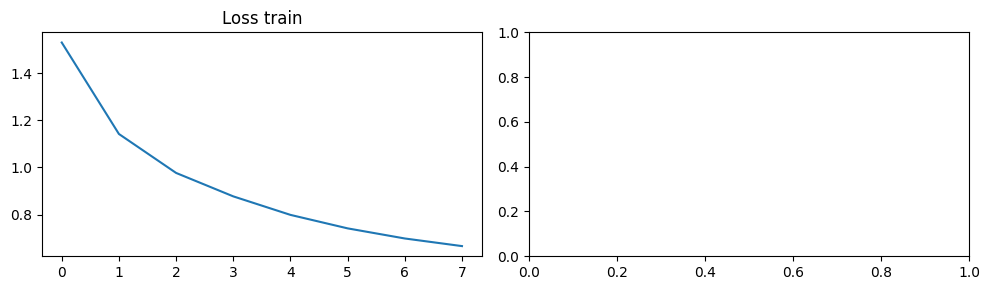

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(historial_train_loss)
ax[0].set_title("Loss train")
plt.tight_layout()
plt.show()
